In [6]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.spectra import sensor_spectra
from src.bulk_parameters import compute_H0, Hs_band
from src.ComplexDemodulation import CD_forced, CD_hourly

In [51]:
# set time window
txi = pd.Timestamp("2008-01-13 12:00:00")
txf = pd.Timestamp("2008-01-15 21:00:00")

IG = (0.004, 0.04)  
SS = (0.04, 0.20)

In [28]:
1/.2

5.0

In [29]:
# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')

# take spectra
S1 = sensor_spectra(df1, nperseg = 1024)
S6 = sensor_spectra(df6, nperseg = 1024)

# compute sig wave heights
H0 = compute_H0(S6)
 
Hs_ig1 = Hs_band(S1,IG[0], IG[1])
Hs_ss1 = Hs_band(S1, SS[0], SS[1])


## Complex Demodulation

### Peak v Centroid $f_0$ Methods

I'm interested to understand the difference between the peak and centroid freq for CD. Does the spread of the two have a physical meaning? Is one more robust than the other? does it depend on applicartion? Am i asking too many questions? do i need a sandwich?

has any physical meaning or if one method is more stable than the other.Using offshore carrier frequencies (0.04-0.20Hz) to compare the two methods. I will run CD on the same data using both methods and then plot them together to see how they differ over time. I will also look at the spread between the two frequencies to see if it 

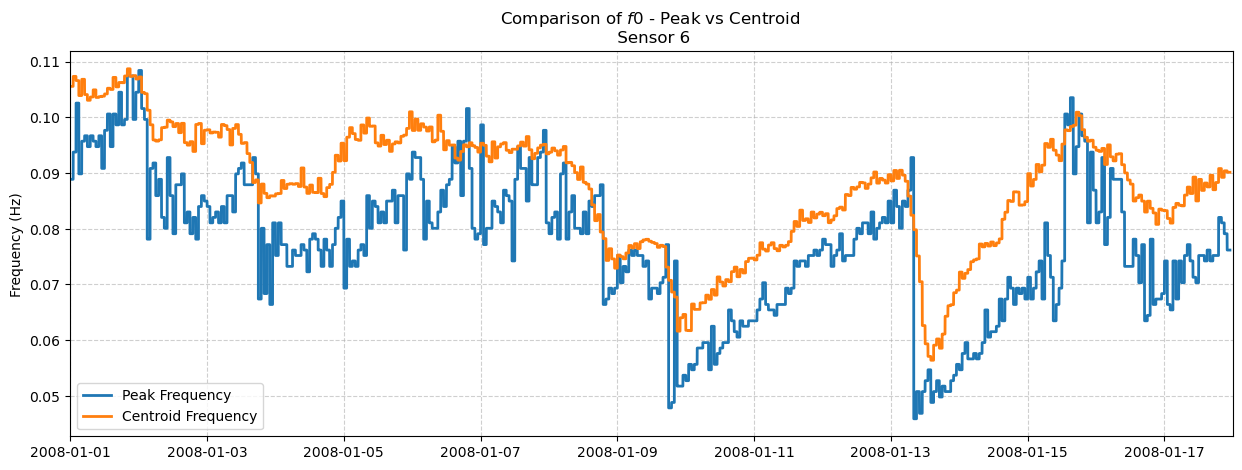

In [119]:

# ---- Run Complex Demodulation (Centroid Method) ---- #
df_cent = CD_hourly (
    df6, txi, txf, p_col="h", f_swell=SS, f0_method='centroid'
)

df_peak = CD_hourly (
    df6, txi, txf, p_col="h", f_swell=SS, f0_method='peak'
)

# Plot the raw f0 series. 
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_peak.index, df_peak['f0'], label='Peak Frequency', color='tab:blue', linewidth=2)
ax.plot(df_cent.index, df_cent['f0'], label='Centroid Frequency', color='tab:orange', linewidth=2)

ax.set_xlim(txi, txf)

# Formatting
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Comparison of $f0$ - Peak vs Centroid \n Sensor 6')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


### using offshore $f_0$ on nearshore CD

Processing 57 hourly blocks...


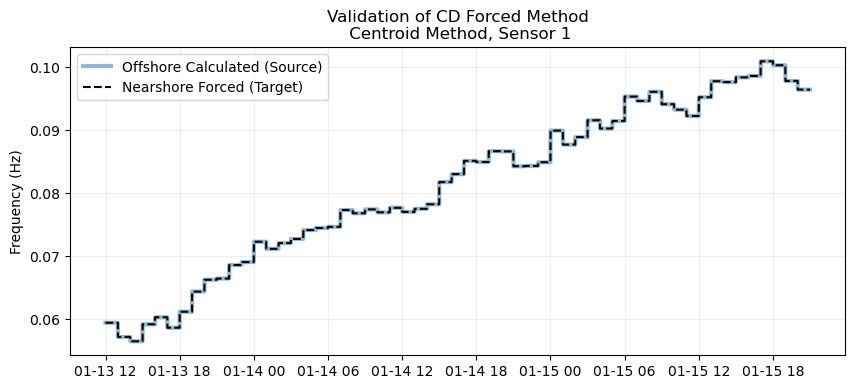

In [52]:

# Use the Peak frequency of df6 to demodulate df1
df1_forced = CD_forced(
    df_target=df1, 
    df_source=df6, 
    start=txi, 
    end=txf, 
    f_swell=SS, 
    f0_method='centroid' 
)
# calculate the standard df6 demodulation just to compare
df6_standard = CD_hourly(df6, txi, txf, f_swell=SS, f0_method='centroid')

plt.figure(figsize=(10, 4))
plt.plot(df6_standard.index, df6_standard['f0'], label='Offshore Calculated (Source)', lw=3, alpha=0.5)
plt.plot(df1_forced.index, df1_forced['f0'], 'k--', label='Nearshore Forced (Target)')
plt.ylabel('Frequency (Hz)')
plt.title('Validation of CD Forced Method\n Centroid Method, Sensor 1')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Processing 57 hourly blocks...


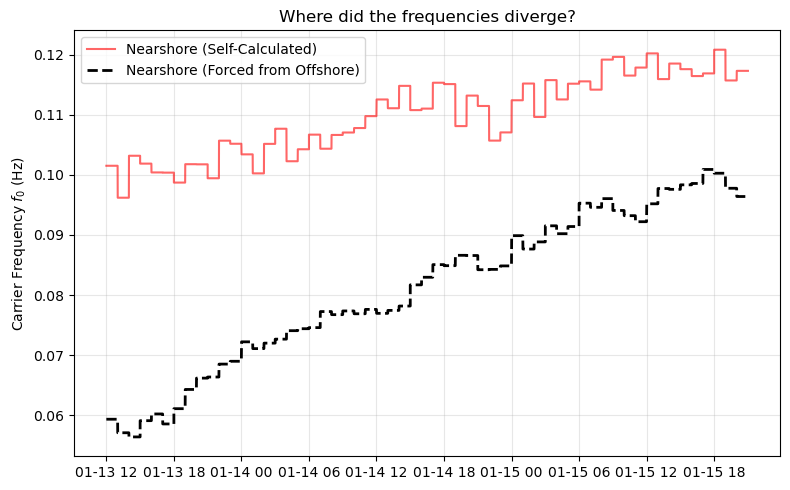

In [ ]:


# Run the Forced Demodulation
# Use the Centroid frequency of df6 (Offshore) to demodulate df1 (Nearshore)
df1_forced =CD_forced(
    df_target=df1, 
    df_source=df6, 
    start=txi, 
    end=txf, 
    f_swell=SS, 
    f0_method='centroid' 
)

# Run Standard Nearshore Demod (Letting it find its own f0)
df1_standard = CD_hourly(
    df1, txi, txf, p_col="h", f_swell=SS, f0_method='centroid'
)

# 3. Plot the comparison
fig, ax1,= plt.subplots(1, 1, figsize=(8, 5), sharex=True)

# f0 comparison
ax1.plot(df1_standard.index, df1_standard['f0'], 'r-', alpha=0.6, label='Nearshore (Self-Calculated)')
ax1.plot(df1_forced.index, df1_forced['f0'], 'k--', lw=2, label='Nearshore (Forced from Offshore)')
ax1.set_ylabel('Carrier Frequency $f_0$ (Hz)')
ax1.set_title('Where did the frequencies diverge?')
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

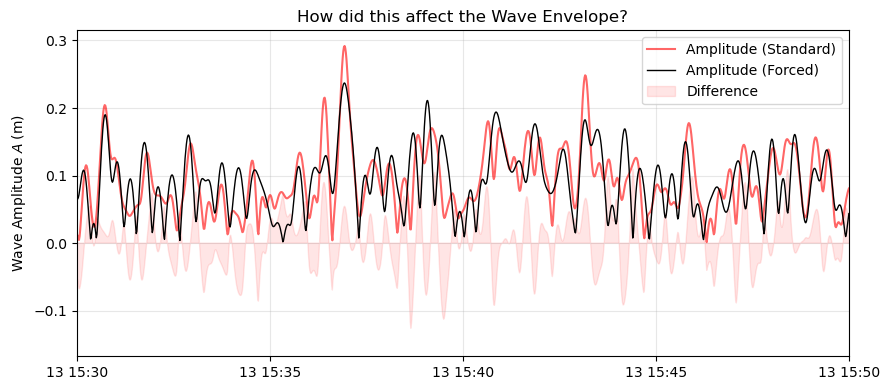

In [64]:
## time to zoom in on
zoom_start = pd.Timestamp("2008-01-13 15:30:00")
zoom_end = pd.Timestamp("2008-01-13 15:50:00")

# amplitude comparison 
fig, ax2 = plt.subplots(1, 1, figsize=(9, 4))
ax2.plot(df1_standard.index, df1_standard['A'], 'r-', alpha=0.6, label='Amplitude (Standard)')
ax2.plot(df1_forced.index, df1_forced['A'], 'k-', lw=1, label='Amplitude (Forced)')

# Highlight the difference
diff = df1_standard['A'] - df1_forced['A']
ax2.fill_between(diff.index, 0, diff, color='red', alpha=0.1, label='Difference')
ax2.set_xlim(zoom_start, zoom_end)
ax2.set_ylabel('Wave Amplitude $A$ (m)')
ax2.set_title('How did this affect the Wave Envelope?')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


After doing **complex demodulation** analysis, I am going to choose to use the **centroid method** for the rest of the analysis, as it seems to provide a more stable and physically meaningful representation of the wave envelope compared to the peak method. The centroid method takes into account the entire energy distribution around the carrier frequency, which can be more robust in cases where the spectrum is broad or has multiple peaks.

Also, using the **forced method** (using the offshore f0) for the nearshore CD analysis will likely provide a more consistent comparison to the offshore conditions

### Complex demodulation + IG wave comparison

In [66]:
## function to get IG wave amplitude from elevation data using butterwoth filter
from scipy.signal import butter, filtfilt, detrend

def get_butter(df, band=(0.004, 0.04), fs=1):
    """
    Compute an infragravity (IG) wave time series from sea-surface elevation data
    using a zero-phase Butterworth bandpass filter.

    The input elevation time series is first linearly detrended to remove
    low-frequency background variability (e.g., tides or sensor drift) that
    can contaminate infragravity-band energy. A Butterworth bandpass filter
    is then applied using forward–backward filtering (`filtfilt`) to isolate
    the IG frequency band while preserving phase.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing a uniformly sampled sea-surface elevation time
        series. Must include a column named `'h'` representing surface
        elevation (meters).
    band : tuple of float, optional
        Two-element tuple specifying the infragravity frequency band
        `(f_low, f_high)` in Hz. Default is (0.004, 0.04) Hz.
    fs : float, optional
        Sampling frequency of the elevation time series in Hz. Default is 1 Hz.

    Returns
    -------
    df : pandas.DataFrame
        Input DataFrame with an additional column `'h_ig'` containing the
        infragravity-band surface elevation time series.

    Notes
    -----
    - Linear detrending removes background variability without affecting
      IG-scale oscillations.
    - A 4th-order Butterworth filter is used; when applied with `filtfilt`,
      the effective magnitude response is approximately 8th order.
    - Zero-phase filtering preserves timing and is appropriate for
      comparisons with wave-group envelopes or other time-domain diagnostics.
    """

    h_detrended = detrend(df['h'].values, type='linear')

    # Design Butterworth bandpass filter
    low, high = band
    nyq = 0.5 * fs
    b, a = butter(N=4, Wn=[low / nyq, high / nyq], btype='band')

    # apply filter
    df['h_ig'] = filtfilt(b, a, h_detrended)

    return df


<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/3864816730.py:13: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(ig1.index, ig1, 'k-', linewidth=1.5, label='IG Surface Elevation $\eta_{IG}$', alpha=0.8)


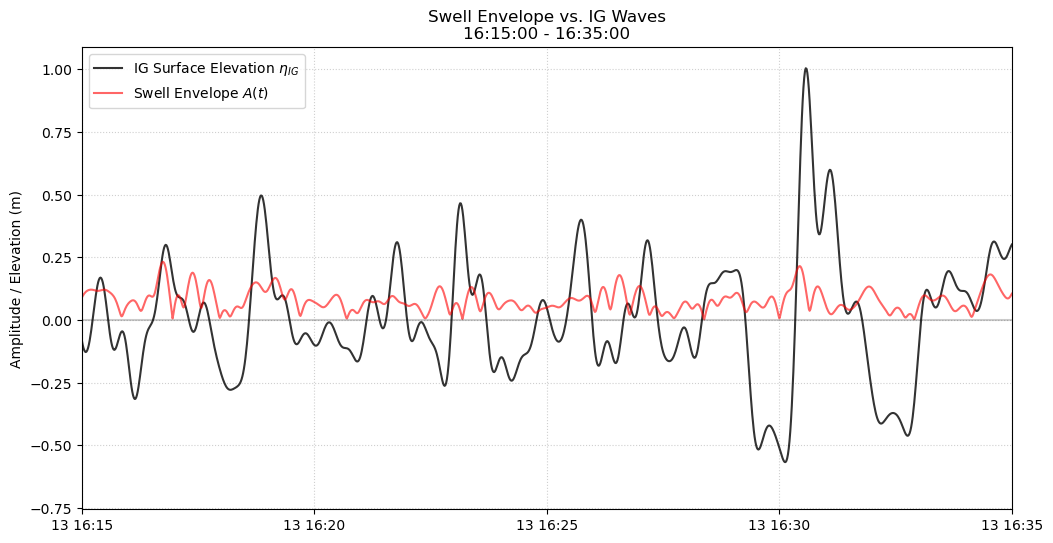

In [71]:
zoom_start = pd.Timestamp("2008-01-13 16:15:00")
zoom_end = pd.Timestamp("2008-01-13 16:35:00")

# sea/swell envelope
ss_envelope = df1_forced['A']
# ig amplitude from butterworth filter
get_butter(df1)
ig1 = pd.Series(df1['h_ig'], index=df1.loc[txi:txf].index)

# plot comparison 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ig1.index, ig1, 'k-', linewidth=1.5, label='IG Surface Elevation $\eta_{IG}$', alpha=0.8)
ax.plot(ss_envelope.index, ss_envelope, 'r-', linewidth=1.5, label='Swell Envelope $A(t)$', alpha=0.6)

# Apply Zoom
ax.set_xlim(zoom_start, zoom_end)

ax.set_title(f'Swell Envelope vs. IG Waves\n{zoom_start.time()} - {zoom_end.time()}')
ax.set_ylabel('Amplitude / Elevation (m)')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)
ax.axhline(0, color='k', linestyle='-', alpha=0.2) # Zero line


I see nothing! going to try splitting the IG bands. Literature suggests that the IG band can be split into low-frequency IG (0.004-0.02 Hz) and high-frequency IG (0.02-0.04 Hz) components, which may have different physical origins and behaviors. By applying the bandpass filter separately to these two sub-bands, I can analyze how each component contributes to the overall IG wave dynamics and how they compare to the CD results.

#### splitting IG bands

In [ ]:
# ---- Configuration ---- #
zoom_start = pd.Timestamp("2008-01-13 16:30:00")
zoom_end   = pd.Timestamp("2008-01-13 16:45:00")

# extract high f IG and lo freq IG
IG_LO = (0.004, 0.02) # bound wave (50s-250s)
IG_HI = (0.02, 0.04) # higher freq (25s-50s)

get_butter(df1, band=IG_LO)
ig_lo = pd.Series(df1['h_ig'], index=df1.loc[txi:txf].index)

get_butter(df1, band=IG_HI)
ig_hi = pd.Series(df1['h_ig'], index=df1.loc[txi:txf].index)


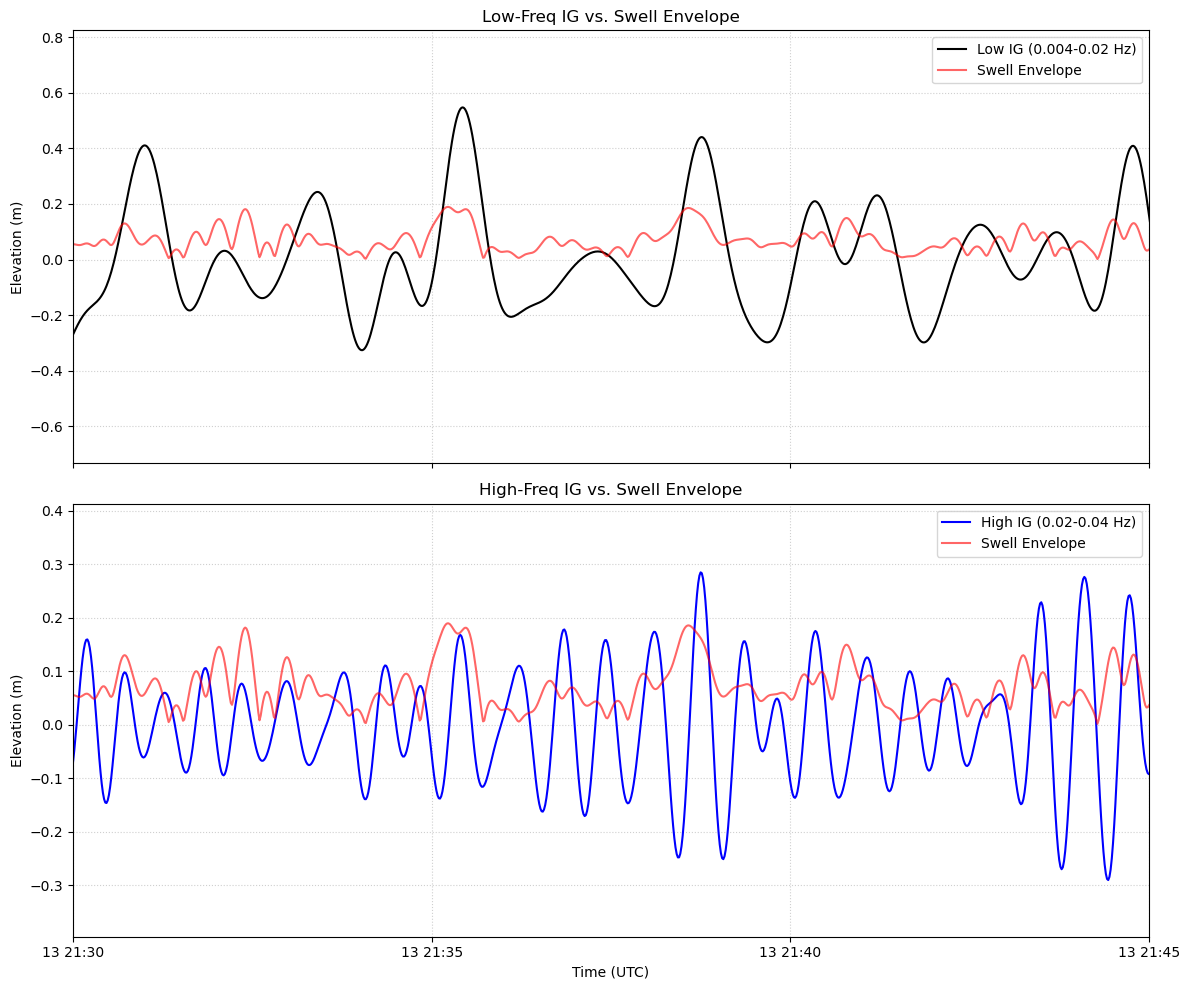

In [76]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# top panel: enevope vs low freq ig
ax1.plot(ig_lo.index, ig_lo, 'k-', linewidth=1.5, label=f'Low IG ({IG_LO[0]}-{IG_LO[1]} Hz)')
ax1.plot(ss_envelope.index, ss_envelope, 'r-', linewidth=1.5, alpha=0.6, label='Swell Envelope')

ax1.set_title(f'Low-Freq IG vs. Swell Envelope')
ax1.set_ylabel('Elevation (m)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Bottom Panel: Envelope vs HIGH FREQ IG ----
# This is often noisier or dominated by reflection/free waves
ax2.plot(ig_hi.index, ig_hi, 'b-', linewidth=1.5, label=f'High IG ({IG_HI[0]}-{IG_HI[1]} Hz)')
ax2.plot(ss_envelope.index, ss_envelope, 'r-', linewidth=1.5, alpha=0.6, label='Swell Envelope')

ax2.set_title(f'High-Freq IG vs. Swell Envelope')
ax2.set_ylabel('Elevation (m)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

# Apply Zoom
ax1.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()

In [90]:
txi = pd.Timestamp("2008-01-13 12:00:00")
txf = pd.Timestamp("2008-01-13 16:00:00")

# Remove duplicate indices (keeping the first occurrence)
df1_forced = df1_forced[~df1_forced.index.duplicated(keep='first')]


common_idx = df1.loc[txi:txf].index
df_scatter = pd.DataFrame(index=common_idx)
# Re-align forced cd results to this index
df_scatter['A'] = df1_forced['A'].reindex(common_idx)
df_scatter['f0'] = df1_forced['f0'].reindex(common_idx)
df_scatter['Tp'] = 1.0 / df_scatter['f0'] 
# IG waves
df_scatter['ig_lo'] = ig_lo.reindex(common_idx)
df_scatter['ig_hi'] = ig_hi.reindex(common_idx)

# Drop any NaNs created by reindexing (edges)
df_scatter = df_scatter.dropna()


<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/3141442930.py:14: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/3141442930.py:29: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_xlabel('High-Freq IG Elevation $\eta_{IG}$ (m)')


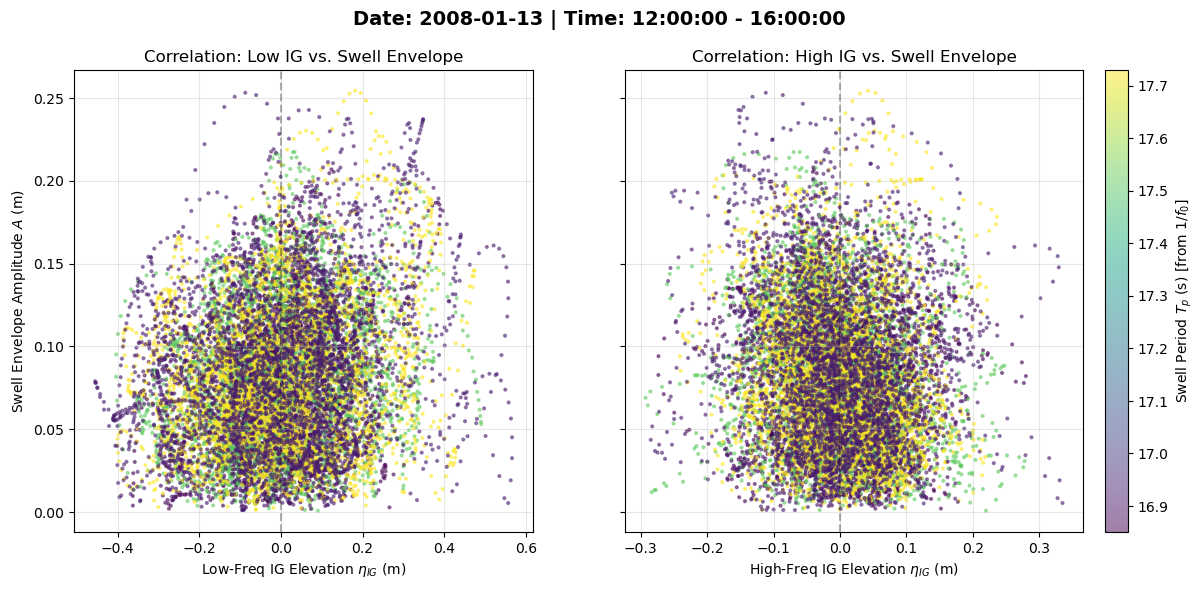

In [92]:
# 2. Plotting the Scatter Correlation
# -----------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---- Plot 1: Low Frequency IG vs. Envelope ----
sc1 = ax1.scatter(
    df_scatter['ig_lo'], 
    df_scatter['A'], 
    c=df_scatter['Tp'], 
    cmap='viridis', 
    s=4, 
    alpha=0.5
)
ax1.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax1.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax1.set_title('Correlation: Low IG vs. Swell Envelope')
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)

# ---- Plot 2: High Frequency IG vs. Envelope ----
sc2 = ax2.scatter(
    df_scatter['ig_hi'], 
    df_scatter['A'], 
    c=df_scatter['Tp'], 
    cmap='viridis', 
    s=4, 
    alpha=0.5
)
ax2.set_xlabel('High-Freq IG Elevation $\eta_{IG}$ (m)')
ax2.set_title('Correlation: High IG vs. Swell Envelope')
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'Date: {txi.date()} | Time: {txi.time()} - {txf.time()}', fontsize=14, fontweight='bold')

# Add Colorbar
cbar = fig.colorbar(sc1, ax=[ax1, ax2], orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('Swell Period $T_p$ (s) [from 1/$f_0$]')

plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/2307171551.py:31: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')


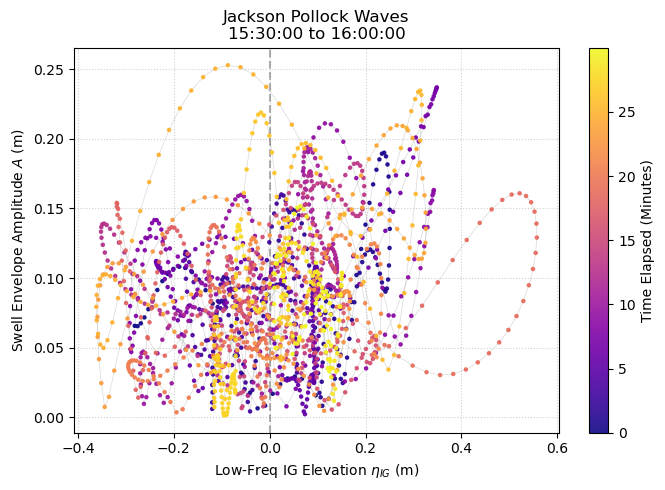

In [98]:

# ---- Configuration ---- #
# Shorten the time window to 3 hours, as you suggested
t_start = pd.Timestamp("2008-01-13 15:30:00")
t_end   = pd.Timestamp("2008-01-13 16:00:00")

# subset data for scatter plot
df_subset = df_scatter.loc[t_start:t_end].copy()

# Create a 'Time Elapsed' array in minutes for the colorbar
time_elapsed_mins = (df_subset.index - df_subset.index[0]).total_seconds() / 60.0

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))

# Draw a faint continuous line connecting the points chronologically.
# This explicitly draws the "orbit" or trajectory the water is taking.
ax.plot(df_subset['ig_lo'], df_subset['A'], color='gray', alpha=0.3, linewidth=0.5)

# Scatter the points on top, colored by the time elapsed
sc = ax.scatter(
    df_subset['ig_lo'], 
    df_subset['A'], 
    c=time_elapsed_mins, 
    cmap='plasma', 
    s=5, 
    alpha=0.9,
    zorder=5 # Keeps the dots on top of the gray line
)

# Formatting
ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax.set_title(f'Jackson Pollock Waves\n{t_start.time()} to {t_end.time()}')
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
ax.grid(True, linestyle=':', alpha=0.6)

# Add the Time Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Time Elapsed (Minutes)')

plt.tight_layout()
plt.show()

#### animating the cd vg ig evolution

In [100]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

# ==========================================
# 1. PREPARE FULL 12-HOUR DATASET
# ==========================================
# (Redoing this briefly to ensure df_scatter covers the full event)
ti_full = pd.Timestamp("2008-01-13 12:00:00")
tf_full = pd.Timestamp("2008-01-15 06:00:00")

# Align Indices
common_idx = df1.loc[ti_full:tf_full].index
df_anim = pd.DataFrame(index=common_idx)

# Remove duplicates in forced data if they exist
df1_forced_clean = df1_forced[~df1_forced.index.duplicated(keep='first')]

# Map Data
df_anim['A'] = df1_forced_clean['A'].reindex(common_idx)
df_anim['f0'] = df1_forced_clean['f0'].reindex(common_idx)
df_anim['ig_lo'] = ig_lo.reindex(common_idx)
df_anim = df_anim.dropna()

# ==========================================
# 2. SETUP ANIMATION
# ==========================================
# Configuration
window_size = pd.Timedelta(minutes=30)
step_size = pd.Timedelta(minutes=5)

# Create the list of start times for each frame
start_times = pd.date_range(start=ti_full, end=tf_full - window_size, freq='5min')

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 8))

# Fix Axes Limits (Crucial so the axis doesn't jump around)
# We add a little 10% buffer
x_min, x_max = df_anim['ig_lo'].min(), df_anim['ig_lo'].max()
y_min, y_max = df_anim['A'].min(), df_anim['A'].max()
ax.set_xlim(x_min * 1.1, x_max * 1.1)
ax.set_ylim(y_min * 0.9, y_max * 1.1)

# Initialize Empty Plots
# 1. The Gray History Line
line, = ax.plot([], [], color='gray', alpha=0.3, linewidth=1.0)
# 2. The Scatter Points
sc = ax.scatter([], [], c=[], cmap='turbo', s=20, alpha=0.9, zorder=5, vmin=0, vmax=30)

# Labels
ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')
ax.set_ylabel('Swell Envelope Amplitude $A$ (m)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)

# Add Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Minutes Elapsed in Window')

# ==========================================
# 3. ANIMATION UPDATE FUNCTION
# ==========================================
def update(frame_time):
    # Define current window
    t_start = frame_time
    t_end = t_start + window_size
    
    # Subset Data
    subset = df_anim.loc[t_start:t_end]
    
    if len(subset) == 0:
        return line, sc

    # Calculate Time Minutes (0 to 30)
    mins = (subset.index - t_start).total_seconds() / 60.0
    
    # Update Line Data
    line.set_data(subset['ig_lo'], subset['A'])
    
    # Update Scatter Data
    # set_offsets expects an (N, 2) array
    offsets = np.column_stack((subset['ig_lo'], subset['A']))
    sc.set_offsets(offsets)
    sc.set_array(mins) # Update colors
    
    # Update Title
    ax.set_title(f'SS Envelope vs IG Evolution (30min Window)\n{t_start.strftime("%H:%M")} - {t_end.strftime("%H:%M")}')
    
    return line, sc

# ==========================================
# 4. RUN AND SAVE
# ==========================================
print(f"Generating animation frames ({len(start_times)} frames)...")

ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=start_times, 
    interval=100, # Milliseconds per frame
    blit=False    # False is slower but safer for titles/colorbars
)

# Save to GIF
save_path = "hysteresis_evolution.gif"
ani.save(save_path, writer='pillow', fps=10)

print(f"Done! Animation saved to: {save_path}")
plt.close() # Prevents static plot from showing in the notebook

<>:54: SyntaxWarning: invalid escape sequence '\e'
<>:54: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/2016274326.py:54: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Low-Freq IG Elevation $\eta_{IG}$ (m)')


Generating animation frames (499 frames)...
Done! Animation saved to: hysteresis_evolution.gif


#### cross correlation of ig and ss envelope

from T&E:
**cross-correlation**: The correlation between corresponding members of 2 or more different series of the same duration:
if $x(t)=(x_1,x_2,...,x_n)$ and $y(t)=(y_1,y_2,...,y_n)$ are two series, then the cross-correlation is given by:
$$R_{xy}(\tau) = E[x(t)y(t+\tau)]$$
where $E$ is the expected value operator and $\tau$ is the time lag. 

The cross-correlation function measures the similarity between the two series as a function of the time lag $\tau$. It can be used to identify any time delay between the two series and to determine if there is a linear relationship between them.

**Task** make a script computes a rolling cross-correlation between the IG wave and the SS envelope and then plots the results as a function of time and lag. This will help us understand how the relationship between the IG wave and the SS envelope evolves over time and if there are any consistent time lags where the correlation is strongest.

In [105]:
## --- rolling cross correlation analysis functino -- ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, butter, filtfilt

def cross_corr(
    envelope, 
    ig_waves, 
    window_min=30, 
    step_min=5, 
    fs=1.0, 
    max_lag_sec=120
):
    """
    Computes a rolling cross-correlation between a wave envelope and IG waves
    following the statistical framework in Thomson & Emery (Section 5.5).

    T&E Process Description:
    ------------------------
    1. Demeaning: For each window, the mean is subtracted from both sequences 
       to focus on the covariance of the fluctuations.
    
    2. Biased Estimator: Computes the cross-covariance C_xy(lag) using the 
       1/N normalization. As noted by T&E, while this is biased, it is often 
       preferred over the 1/(N-|m|) estimator because it results in lower 
       mean-square error and ensures the correlation sequence is 
       mathematically well-behaved.

    3. Normalization: The cross-covariance is normalized by the product of the 
       individual standard deviations (sqrt(var_x * var_y)) to yield the 
       dimensionless correlation coefficient, rho_xy, ranging from -1 to 1.
    
    4. Peak Detection: Identifies the maximum absolute correlation within 
       physically relevant time lags (e.g., travel time from reef edge to sensor).

    Parameters:
    -----------
    envelope : pd.Series
        The 'Lead' signal (e.g., the swell envelope from complex_demod).
    ig_waves : pd.Series
        The 'Follower' signal (e.g., the h_ig result from get_butter).
    window_min : int
        Duration of the analysis window in minutes.
    step_min : int
        The stride/overlap between windows in minutes.
    fs : float
        Sampling frequency in Hz.
    max_lag_sec : float
        The physical window (seconds) to search for the correlation peak.
    """
    # Define Timesteps
    window_size = pd.Timedelta(minutes=window_min)
    step_size = pd.Timedelta(minutes=step_min)
    
    start_time = envelope.index[0]
    end_time = envelope.index[-1] - window_size
    
    results = []
    times = []
    
    current_time = start_time
    
    print(f"Running Rolling Analysis ({window_min}m windows)...")
    
    while current_time <= end_time:
        # 1. Slice Window
        t_end = current_time + window_size
        env_win = envelope.loc[current_time:t_end]
        ig_win = ig_waves.loc[current_time:t_end]
        
        # Check data integrity
        if len(env_win) < 100 or len(ig_win) < 100:
            current_time += step_size
            continue
            
        # 2. Compute Thomson & Emery Cross-Correlation
        # Demean
        x = env_win.values - np.mean(env_win.values)
        y = ig_win.values - np.mean(ig_win.values)
        N = len(x)
        
        # Normalization factors (Variance)
        var_x = np.sum(x**2) / N
        var_y = np.sum(y**2) / N
        denom = np.sqrt(var_x * var_y)
        
        # Cross-Covariance (Biased Estimator)
        cov = correlate(x, y, mode='full', method='fft') / N
        rho = cov / denom
        
        # Lags
        lags = np.arange(-(N-1), N) / fs
        
        # 3. Find Peak within physical limits
        mask = (lags >= -max_lag_sec) & (lags <= max_lag_sec)
        lags_lim = lags[mask]
        rho_lim = rho[mask]
        
        # Find absolute max correlation (could be negative for bound waves!)
        idx_max = np.argmax(np.abs(rho_lim))
        
        peak_corr = rho_lim[idx_max]
        peak_lag = lags_lim[idx_max]
        
        results.append((peak_corr, peak_lag))
        times.append(current_time + window_size/2) # Plot at center of window
        
        current_time += step_size
        
    return pd.DataFrame(results, index=times, columns=['Correlation', 'Lag_sec'])


In [ ]:
txi = pd.Timestamp("2008-01-01 00:00:00")
txf = pd.Timestamp("2008-01-17 23:59:59")

s_env = CD_forced(df_target=df1, df_source=df6, start=txi, end=txf, f_swell=SS, f0_method='centroid')['A']
ig_lo = get_butter(df1, band=IG_LO)['h_ig']



# Remove any duplicate timestamps that occurred during hourly concatenation
if isinstance(ss_envelope, pd.Series) or isinstance(ss_envelope, pd.DataFrame):
    ss_envelope = ss_envelope[~ss_envelope.index.duplicated(keep='first')]

# use whole time series
idx = df1.index
# Reindex the ss_envelope and ig_lo to match the full index, using nearest method to fill any gaps
#s_env = ss_envelope.reindex(idx, method='nearest', tolerance=pd.Timedelta('1s'))
#s_ig = ig_lo.reindex(idx, method='nearest', tolerance=pd.Timedelta('1s'))

print("Starting Rolling Analysis...")
df_roll = cross_corr(
    s_env.dropna(),     # Drop NaNs to avoid errors in correlation
    s_ig.dropna(), 
    window_min=30,      # 30-minute sliding window
    step_min=5          # Step forward 5 minutes
)


Processing 407 hourly blocks...
Starting Rolling Analysis...
Running Rolling Analysis (30m windows)...


IndexError: boolean index did not match indexed array along dimension 0; dimension is 3600 but corresponding boolean dimension is 3601

In [117]:
import pandas as pd

# 1. Define the "Big Event" Time Range
txi = pd.Timestamp("2008-01-01 00:00:00")
txf = pd.Timestamp("2008-01-17 23:59:59")

print(f"--- Processing: {txi.date()} to {txf.date()} ---")

# 2. Get the Swell Envelope (The 'Leader' / Reference)
# Using the 'Chaperone' offshore (df6) to guide the Target nearshore (df1)
s_env = CD_forced(
    df_target=df1, 
    df_source=df6, 
    start=txi, 
    end=txf, 
    f_swell=SS, 
    f0_method='centroid'
)['A']

# 3. Get the IG Waves (The 'Follower' / Target)
# 'Get the butter' by filtering df1 to the IG band
# We subset it immediately to match the time range of our envelope
ig_data = get_butter(df1.loc[txi:txf], band=IG_LO)
s_ig = ig_data['h_ig']

# 4. Clean up Duplicates & Align the 'Dance Partners'
# Sometimes hourly concatenation leaves a double-stamp at the top of the hour
s_env = s_env[~s_env.index.duplicated(keep='first')]
s_ig = s_ig[~s_ig.index.duplicated(keep='first')]

# Synchronize the two series to a common index to ensure perfect timing
common_idx = s_env.index.intersection(s_ig.index)
s_env_final = s_env.reindex(common_idx)
s_ig_final = s_ig.reindex(common_idx)

# 5. Run the Rolling Analysis
print(f"Starting Rolling Analysis (Analyzing {len(s_env_final)} points)...")
df_roll = cross_corr(
    s_env_final.dropna(), 
    s_ig_final.dropna(), 
    window_min=30,      # 30-minute sliding window
    step_min=10,        # Increased step to 10m for speed over 17 days
    fs=1.0,
    max_lag_sec=120     # Look for the peak within 2 minutes
)

print("Analysis complete!")

--- Processing: 2008-01-01 to 2008-01-17 ---
Processing 407 hourly blocks...


/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_89953/899630915.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['h_ig'] = filtfilt(b, a, h_detrended)


Starting Rolling Analysis (Analyzing 1464539 points)...
Running Rolling Analysis (30m windows)...
Analysis complete!


DONE. Best Correlation: 0.598 at 2008-01-13 21:25:01.000004608
Lag at that time: -9.0 seconds


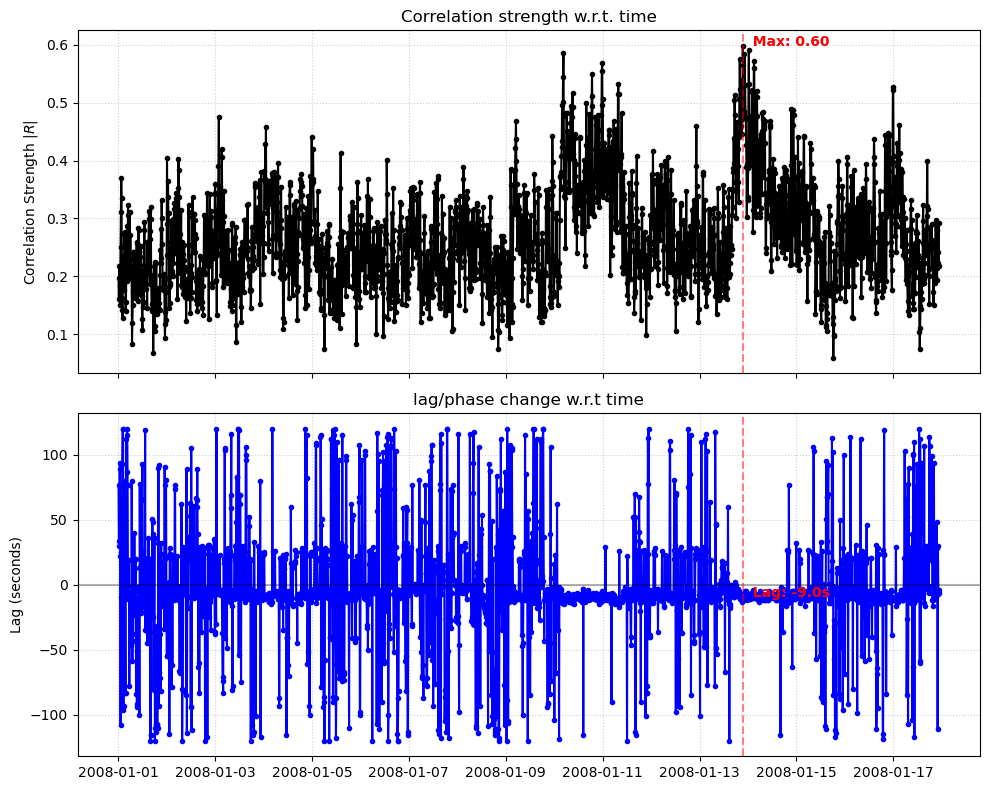

In [118]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Correlation Strength
ax1.plot(df_roll.index, np.abs(df_roll['Correlation']), 'k-', marker='.', linewidth=1.5)
ax1.set_ylabel('Correlation Strength $|R|$')
ax1.set_title('Correlation strength w.r.t. time')
ax1.grid(True, linestyle=':', alpha=0.6)

# Highlight Best Window
if not df_roll.empty:
    best_time = df_roll['Correlation'].abs().idxmax()
    best_val = df_roll['Correlation'].abs().max()
    ax1.axvline(best_time, color='r', linestyle='--', alpha=0.5)
    ax1.text(best_time, best_val, f'  Max: {best_val:.2f}', color='r', fontweight='bold')

    # Plot 2: Lag Evolution
    ax2.plot(df_roll.index, df_roll['Lag_sec'], 'b-', marker='.', linewidth=1.5)
    ax2.set_ylabel('Lag (seconds)')
    ax2.set_title('lag/phase change w.r.t time')
    ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Annotate Best Lag
    best_lag = df_roll.loc[best_time, 'Lag_sec']
    ax2.axvline(best_time, color='r', linestyle='--', alpha=0.5)
    ax2.text(best_time, best_lag, f'  Lag: {best_lag:.1f}s', color='r', fontweight='bold', va='baseline')
    
    print(f"DONE. Best Correlation: {best_val:.3f} at {best_time}")
    print(f"Lag at that time: {best_lag:.1f} seconds")
else:
    print("Warning: No results found. Check your input data alignment.")

plt.tight_layout()
plt.show()

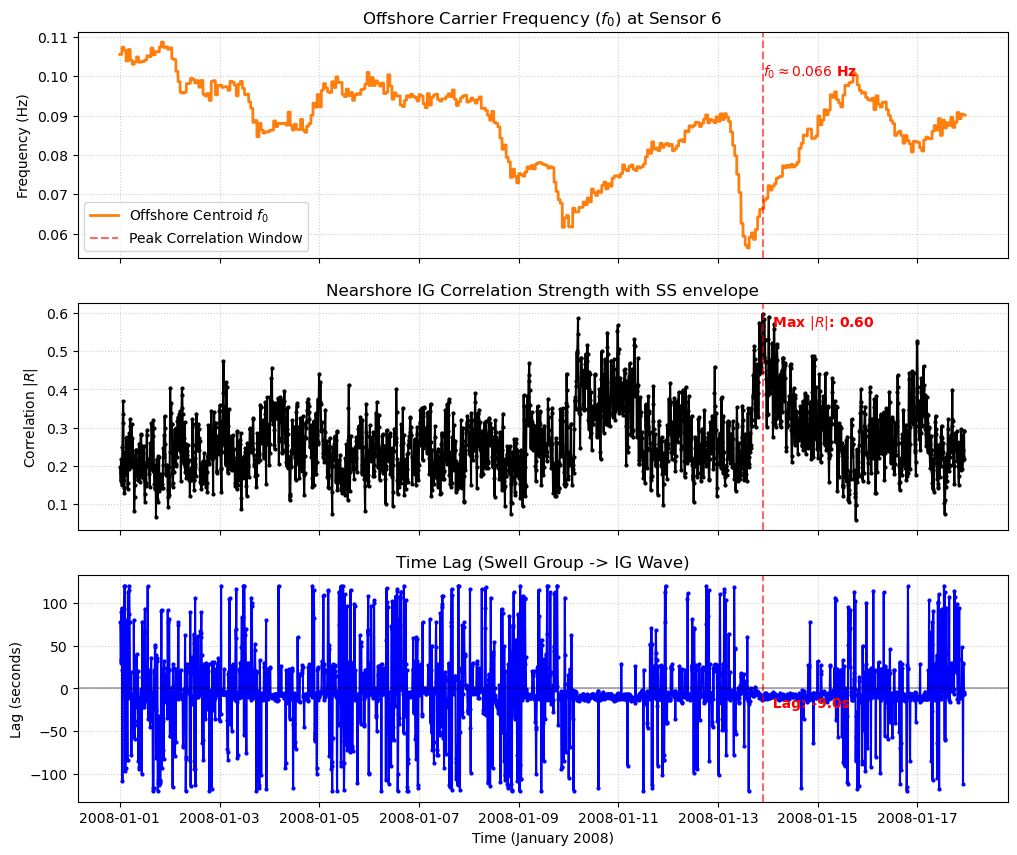

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the 3-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 2. Find the "Best Correlated Window" 
if not df_roll.empty:
    # Use absolute value to find the strongest relationship (positive or negative)
    best_time = df_roll['Correlation'].abs().idxmax()
    best_val = df_roll['Correlation'].abs().max()
    best_lag = df_roll.loc[best_time, 'Lag_sec']
    best_f0 = df_cent.loc[best_time:best_time + pd.Timedelta(minutes=30), 'f0'].mean() # Approx f0 at that time
    
    # --- Panel 1: Offshore Frequency (The Driver) ---
    ax1.plot(df_cent.index, df_cent['f0'], color='tab:orange', linewidth=2, label='Offshore Centroid $f_0$')
    ax1.axvline(best_time, color='r', linestyle='--', alpha=0.6, label='Peak Correlation Window')
# The 'r' before the string handles the backslash, 
# and the $ encapsulates the whole math expression.
    ax1.text(best_time, ax1.get_ylim()[1]*0.9, rf'$f_0 \approx {best_f0:.3f}$ Hz', color='r', fontweight='bold')    
    ax1.set_ylabel('Frequency (Hz)')
    ax1.set_title('Offshore Carrier Frequency ($f_0$) at Sensor 6')
    ax1.legend(loc='lower left')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- Panel 2: Correlation Strength (The Relationship) ---
    ax2.plot(df_roll.index, df_roll['Correlation'].abs(), 'k-', marker='.', markersize=4)
    ax2.axvline(best_time, color='r', linestyle='--', alpha=0.6)
    ax2.text(best_time, best_val, f'  Max $|R|$: {best_val:.2f}', color='r', fontweight='bold', va='top')
    ax2.set_ylabel('Correlation $|R|$')
    ax2.set_title('Nearshore IG Correlation Strength with SS envelope')
    ax2.grid(True, linestyle=':', alpha=0.6)

    # --- Panel 3: Lag Evolution (The Travel Time) ---
    ax3.plot(df_roll.index, df_roll['Lag_sec'], 'b-', marker='.', markersize=4)
    ax3.axvline(best_time, color='r', linestyle='--', alpha=0.6)
    ax3.text(best_time, best_lag, f'  Lag: {best_lag:.1f}s', color='r', fontweight='bold', va='top')
    ax3.axhline(0, color='k', linestyle='-', alpha=0.3)
    ax3.set_ylabel('Lag (seconds)')
    ax3.set_xlabel('Time (January 2008)')
    ax3.set_title('Time Lag (Swell Group -> IG Wave)')
    ax3.grid(True, linestyle=':', alpha=0.6)

    # Zoom

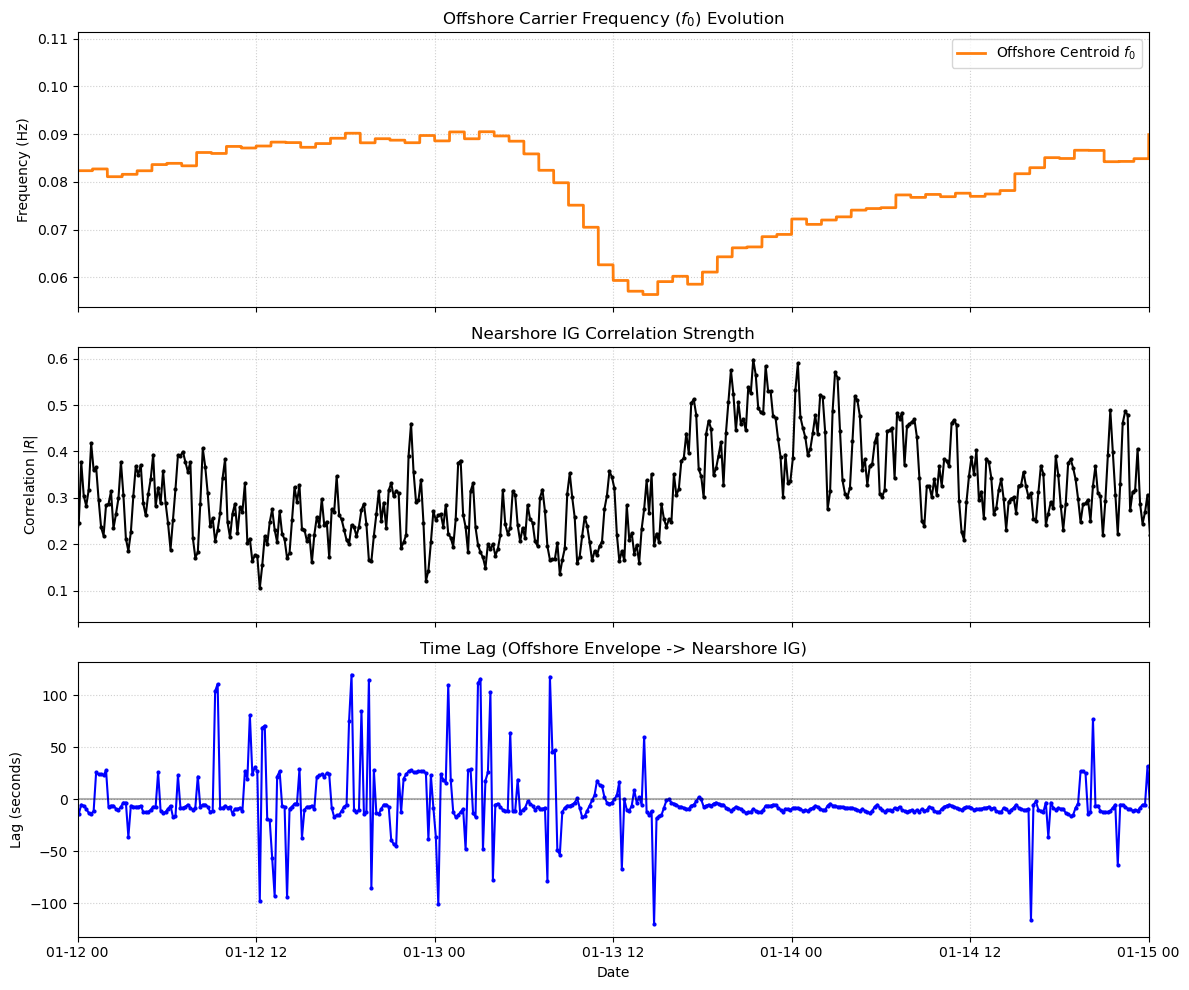

In [ ]:
# Create a 3-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot Offshore Centroid Frequency=
ax1.plot(df_cent.index, df_cent['f0'], color='tab:orange', linewidth=2, label='Offshore Centroid $f_0$')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Offshore Carrier Frequency ($f_0$) Evolution')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# 2. Plot Correlation Strength 
ax2.plot(df_roll.index, df_roll['Correlation'].abs(), 'k-', marker='.', markersize=4)
ax2.set_ylabel('Correlation $|R|$')
ax2.set_title('Nearshore IG Correlation Strength')
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. Plot Lag
ax3.plot(df_roll.index, df_roll['Lag_sec'], 'b-', marker='.', markersize=4)
ax3.set_ylabel('Lag (seconds)')
ax3.set_title('Time Lag (Offshore Envelope -> Nearshore IG)')
ax3.axhline(0, color='k', linestyle='-', alpha=0.3)
ax3.set_xlabel('Date')
ax3.grid(True, linestyle=':', alpha=0.6)

# Formatting: Zoom into the Jan 13 peak
ax3.set_xlim(pd.Timestamp("2008-01-12"), pd.Timestamp("2008-01-15"))

plt.tight_layout()
plt.show()

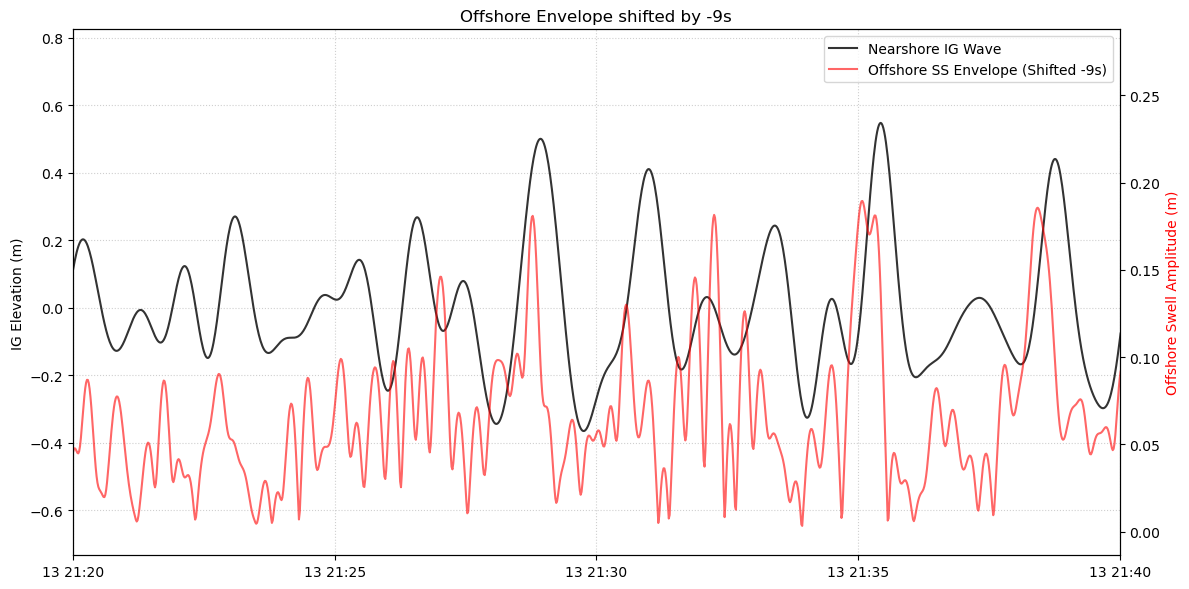

In [133]:
LAG_OFFSHORE_SEC = -9  
zoom_start = pd.Timestamp("2008-01-13 21:20:00")
zoom_end   = pd.Timestamp("2008-01-13 21:40:00")
fs=1

ss_env_shift = ss_envelope.shift(periods=int(LAG_OFFSHORE_SEC * fs))

fig, (ax1) = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# ---- PLOT 1: Offshore Envelope vs. Nearshore IG ----
# This visualizes the "Travel Time" and "Dispersion"
ax1.plot(s_ig.index, s_ig, 'k-', linewidth=1.5, label='Nearshore IG Wave', alpha=0.8)

# We use a twinx axis because Offshore waves are likely much bigger than Nearshore IG
ax1b = ax1.twinx()
ax1b.plot(ss_env_shift.index, ss_env_shift, 'r-', linewidth=1.5, alpha=0.6, 
          label=f'Offshore SS Envelope (Shifted {LAG_OFFSHORE_SEC}s)')

# Formatting
ax1.set_title(f'Offshore Envelope shifted by {LAG_OFFSHORE_SEC}s')
ax1.set_ylabel('IG Elevation (m)')
ax1b.set_ylabel('Offshore Swell Amplitude (m)', color='r')
ax1.grid(True, linestyle=':', alpha=0.6)

# Legend (Manually combined)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


# Apply Zoom
ax1.set_xlim(zoom_start, zoom_end)

plt.tight_layout()
plt.show()
